# Scribble – Datenerkundung: Marken, Stationen & Aggregationsstrategien

Dieses Notebook ergänzt `spritpreis_mlp.ipynb` (CRISP-DM Phase 2 Vorbereitung).

**Ziele:**
- Stationsmetadaten laden und Marken (Brands) analysieren
- Aggregationsstrategien entwickeln: Regional und nach Marke
- Grundlage für Phase 2 schaffen: regionale oder markenbasierte Modelle

---
## §0 – Setup & Konfiguration

In [3]:
# ── Standardbibliotheken ──────────────────────────────────────────────────────
import glob
from pathlib import Path

# ── Numerik & Daten ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisierung ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Plot-Styling (konsistent mit spritpreis_mlp.ipynb) ───────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})

# ── Pfadkonfiguration ─────────────────────────────────────────────────────────
#
# DATA_RAW      : Preisordner (identisch zu spritpreis_mlp.ipynb)
# STATION_FILE  : Stationsmetadaten (UUID, Name, Marke, PLZ, Koordinaten)
# DATA_PROC     : Cache-Ordner für aggregierte Parquet-Dateien

DATA_RAW     = Path('../tankerkoenig-data/prices')
STATION_FILE = Path('../tankerkoenig-data/stations/stations.csv')
DATA_PROC    = Path('data/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

print('Preisordner existiert   :', DATA_RAW.exists())
print('Stations-CSV existiert  :', STATION_FILE.exists())

Preisordner existiert   : True
Stations-CSV existiert  : True


---
## §1 – Stationsdaten laden

Die Stations-CSV enthält Metadaten zu jeder deutschen Tankstelle:

| Spalte | Beschreibung |
|---|---|
| `uuid` | Eindeutige ID – Verbindungsschlüssel zu den Preis-CSVs |
| `name` | Name der Tankstelle |
| `brand` | Marke (Freitext – enthält Schreibvarianten) |
| `street`, `house_number` | Adresse |
| `post_code` | Postleitzahl (5-stellig) |
| `city` | Ort |
| `latitude`, `longitude` | Koordinaten für regionale Zuordnung |

In [4]:
# Stationsdatei vollständig einlesen – sie ist klein (< 10 MB) und passt
# problemlos in den Arbeitsspeicher, anders als die 89 GB Preis-CSVs.

stations = pd.read_csv(STATION_FILE, low_memory=False)

print(f'Stationen gesamt : {len(stations):,}')
print(f'Spalten          : {stations.columns.tolist()}')
print()
print('Fehlende Werte:')
print(stations.isnull().sum())
print()
stations.head(5)

Stationen gesamt : 15,442
Spalten          : ['uuid', 'name', 'brand', 'street', 'house_number', 'post_code', 'city', 'latitude', 'longitude']

Fehlende Werte:
uuid               0
name               0
brand            544
street             2
house_number    3678
post_code          2
city               3
latitude           0
longitude          0
dtype: int64



,uuid,name,brand,street,house_number,post_code,city,latitude,longitude
0,00060723-0001-4444-8888-acdc00000001,BAGeno Raiffeisen eG,NaN,Künzelsauer Strasse,7,74653,Ingelfingen,49.296822,9.661385
1,005056ba-7cb6-1ed2-bceb-5332ab168d12,famila Tankstelle,FAMILA,Pascalstrasse,9,25442,Quickborn,53.742150,9.941240
2,005056ba-7cb6-1ed2-bceb-573c18314d16,star Tankstelle,STAR,Riehler Strasse,240,50735,Köln,50.961800,6.980070
3,005056ba-7cb6-1ed2-bceb-662ba1a94d1f,star Tankstelle,STAR,BAB 10 / Seeberg Ost,NaN,15345,Altlandsberg,52.550160,13.682120
4,005056ba-7cb6-1ed2-bceb-6f7b23564d23,star Tankstelle,STAR,Duisburger Straße,130,47166,Duisburg,51.489790,6.783730


---
## §2 – Marken (Brands) analysieren

### §2.1 – Rohe Markennamen zählen

Tankerkoenig speichert Marken als Freitext-Feld → viele Schreibvarianten
(z. B. `"ARAL"`, `"Aral"`, `"aral  "`).
Wir schauen uns zuerst die Rohdaten an, um zu verstehen, wie viel Bereinigung nötig ist.

In [5]:
# Rohe Zählung inklusive NaN – noch keinerlei Bereinigung.
# dropna=False stellt sicher, dass fehlende Markennamen als eigene Kategorie gezählt werden.

raw_brand_counts = stations['brand'].value_counts(dropna=False)

print(f'Eindeutige Markennamen (roh, inkl. NaN): {raw_brand_counts.shape[0]}')
print()
print('Top 40 Markennamen (roh):')
print(raw_brand_counts.head(40).to_string())

Eindeutige Markennamen (roh, inkl. NaN): 900

Top 40 Markennamen (roh):
brand
ARAL                                     2378
Shell                                    1791
ESSO                                     1066
TOTAL                                     893
AVIA                                      753
JET                                       671
STAR                                      566
NaN                                       544
Agip                                      434
Raiffeisen                                401
HEM                                       384
OMV                                       288
bft                                       246
OIL!                                      233
BFT                                       205
Freie Tankstelle                          195
SB                                        192
Westfalen                                 167
CLASSIC                                   116
ED                                        107
fr

### §2.2 – Marken normalisieren

Strategie:
1. Strip Whitespace + Uppercase → entfernt reine Tipp-Varianten
2. Manuelles Alias-Mapping → fasst bekannte Schreibweisen zusammen
3. Alles Unbekannte → `SONSTIGE` (freie Tankstellen, Eigenmarken, …)

In [6]:
# Schritt 1: Normalisierung
stations['brand_clean'] = (
    stations['brand']
    .fillna('')
    .str.strip()
    .str.upper()
)

# Schritt 2: Alias-Mapping
# Erweiterbar – nach Ausführung von §2.1 können weitere Einträge ergänzt werden.
ALIAS_MAP = {
    'ARAL'              : 'ARAL',
    'BP'                : 'BP',
    'SHELL'             : 'SHELL',
    'SHELL EXPRESS'     : 'SHELL',
    'JET'               : 'JET',
    'ESSO'              : 'ESSO',
    'TOTAL'             : 'TOTALENERGIES',
    'TOTALENERGIES'     : 'TOTALENERGIES',
    'AGIP'              : 'ENI/AGIP',
    'ENI'               : 'ENI/AGIP',
    'AVIA'              : 'AVIA',
    'STAR'              : 'STAR',
    'HEM'               : 'HEM',
    'WESTFALEN'         : 'WESTFALEN',
    'OIL!'              : 'OIL!',
    'RAIFFEISEN'        : 'RAIFFEISEN',
    'BFT'               : 'BFT',
    'ORLEN'             : 'ORLEN',
    'SPRINT'            : 'SPRINT',
    'TAMOIL'            : 'TAMOIL',
    'GO'                : 'GO',
    ''                  : 'SONSTIGE',
}

stations['brand_norm'] = stations['brand_clean'].map(
    lambda b: ALIAS_MAP.get(b, 'SONSTIGE')
)

brand_counts = stations['brand_norm'].value_counts()
print(f'Normalisierte Marken-Kategorien: {brand_counts.shape[0]}')
print()
print(brand_counts.to_string())

Normalisierte Marken-Kategorien: 18

brand_norm
SONSTIGE         5054
ARAL             2378
SHELL            1821
ESSO             1066
TOTALENERGIES     893
AVIA              754
JET               671
STAR              566
BFT               482
ENI/AGIP          434
RAIFFEISEN        401
HEM               384
OIL!              233
WESTFALEN         167
SPRINT             84
GO                 39
TAMOIL             14
ORLEN               1


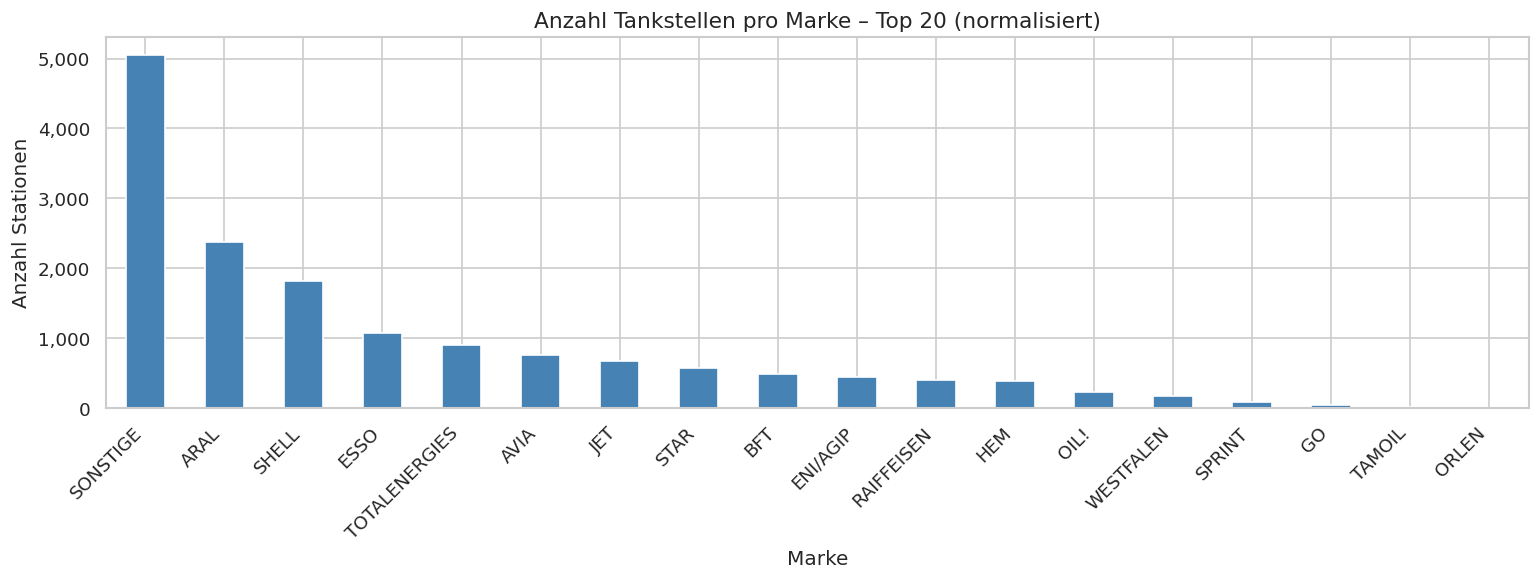

SONSTIGE-Anteil: 32.7 %


In [7]:
# Visualisierung: Stationsanzahl pro Marke (Top 20)

fig, ax = plt.subplots(figsize=(13, 5))
brand_counts.head(20).plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Anzahl Tankstellen pro Marke – Top 20 (normalisiert)', fontsize=13)
ax.set_xlabel('Marke')
ax.set_ylabel('Anzahl Stationen')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'SONSTIGE-Anteil: {brand_counts["SONSTIGE"]/brand_counts.sum()*100:.1f} %')

---
## §3 – Regionale Aufteilung

### Strategie: PLZ-erste-Ziffer als grobe Regionskennung

Die erste Ziffer der Postleitzahl (0–9) teilt Deutschland in zehn grobe Regionen.
Das ist schnell, benötigt keine externe Bibliothek und erzeugt ausreichend
homogene Gruppen für eine Regionalaggregation.

Alternative (präziser aber aufwändiger): Reverse-Geocoding über `lat/lon` → Bundesland.

In [8]:
# PLZ → Region Mapping (erste Ziffer → Name)
PLZ_REGION = {
    '0': 'Ost',
    '1': 'Nordost',
    '2': 'Nord',
    '3': 'Nordwest',
    '4': 'West',
    '5': 'Mitte-West',
    '6': 'Mitte',
    '7': 'Südwest',
    '8': 'Süd',
    '9': 'Südost',
}

# PLZ auf 5 Stellen mit führenden Nullen auffüllen, dann erste Ziffer nehmen.
stations['plz_str'] = stations['post_code'].astype(str).str.zfill(5)
stations['region']  = stations['plz_str'].str[0].map(PLZ_REGION).fillna('Unbekannt')

print('Stationsanzahl pro Region:')
print(stations['region'].value_counts().to_string())

Stationsanzahl pro Region:
region
Nordwest      1964
Nord          1872
West          1852
Mitte-West    1697
Südwest       1611
Südost        1595
Süd           1498
Mitte         1315
Ost           1057
Nordost        978
Unbekannt        3


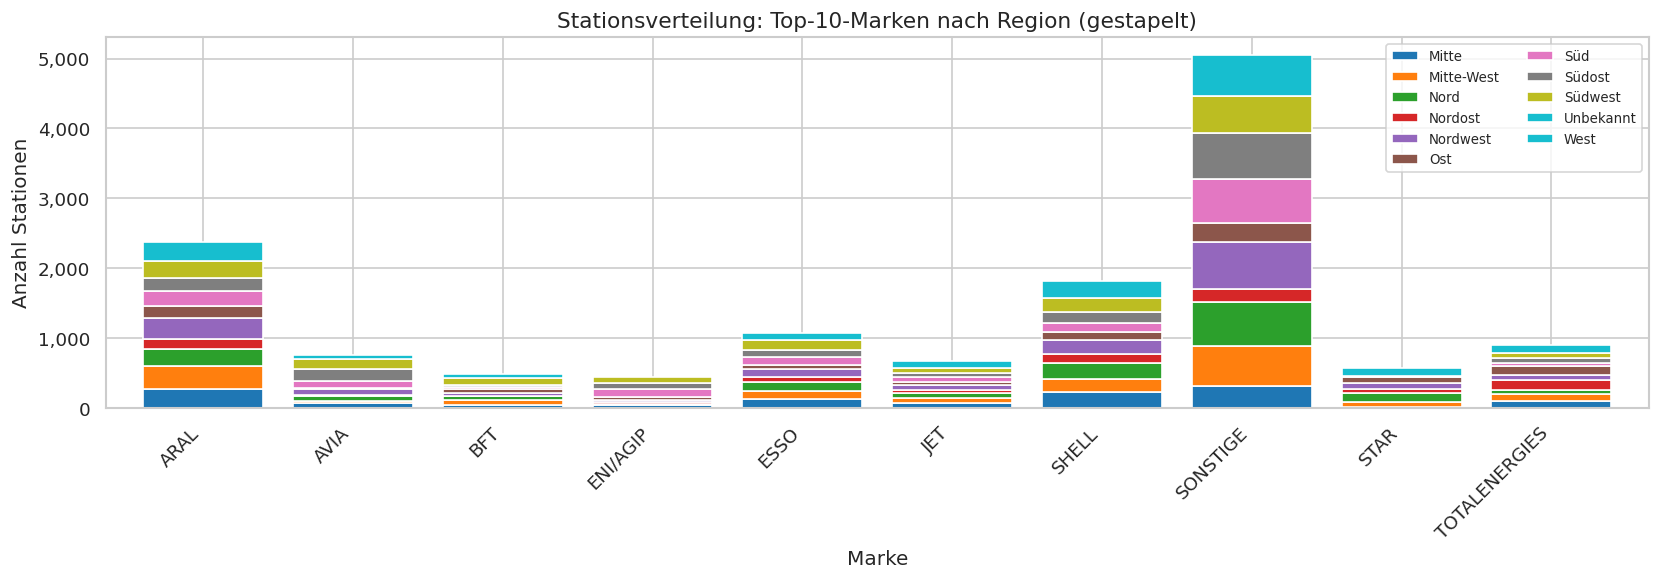

In [9]:
# Kreuztabelle: Top-10-Marken × Region
# Zeigt, ob Marken regional konzentriert sind oder bundesweit verteilt.

top10_brands = brand_counts.head(10).index
cross = pd.crosstab(
    stations.loc[stations['brand_norm'].isin(top10_brands), 'brand_norm'],
    stations.loc[stations['brand_norm'].isin(top10_brands), 'region']
)

fig, ax = plt.subplots(figsize=(14, 5))
cross.plot.bar(ax=ax, stacked=True, colormap='tab10', edgecolor='white', width=0.8)
ax.set_title('Stationsverteilung: Top-10-Marken nach Region (gestapelt)', fontsize=13)
ax.set_xlabel('Marke')
ax.set_ylabel('Anzahl Stationen')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

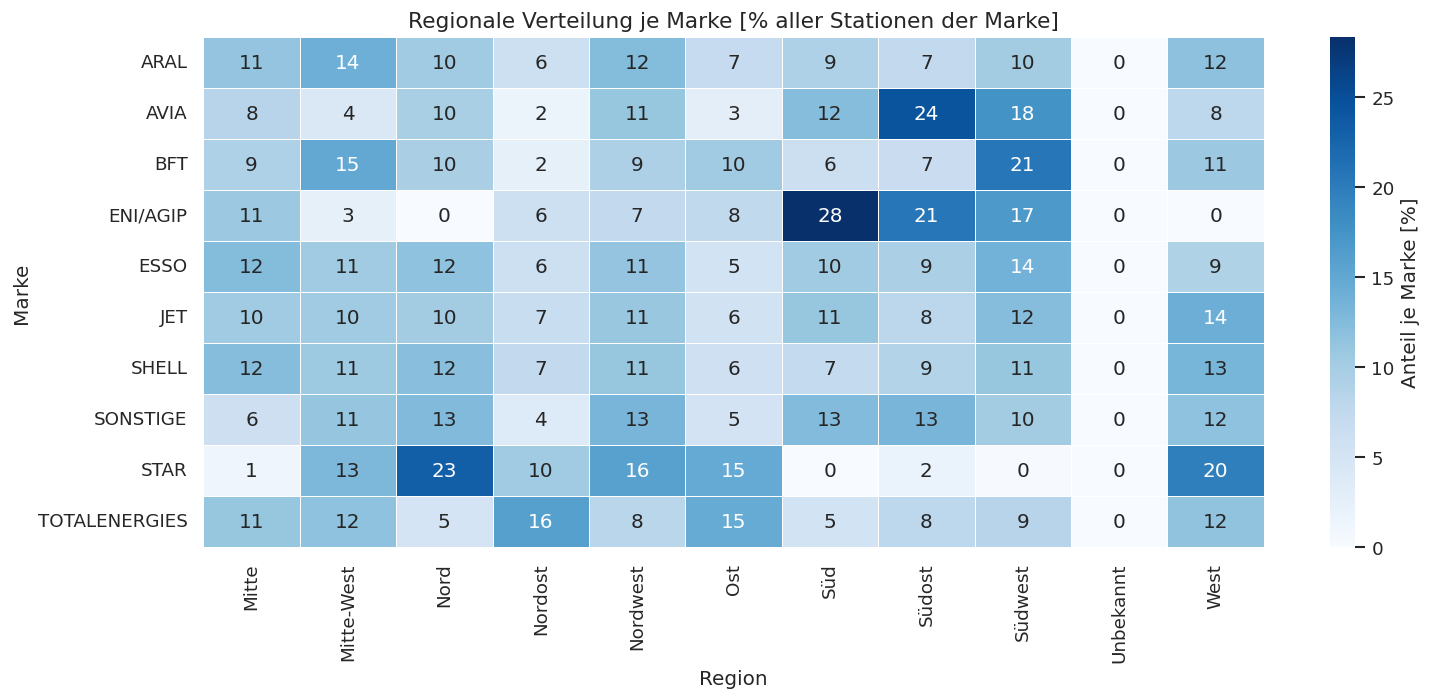

In [10]:
# Heatmap: Marke × Region (normiert auf Zeilen = 100 % je Marke)
# Zeigt die relative regionale Präsenz einer Marke.

cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    cross_pct, annot=True, fmt='.0f', cmap='Blues',
    cbar_kws={'label': 'Anteil je Marke [%]'},
    linewidths=0.5, ax=ax
)
ax.set_title('Regionale Verteilung je Marke [% aller Stationen der Marke]', fontsize=13)
ax.set_xlabel('Region')
ax.set_ylabel('Marke')
plt.tight_layout()
plt.show()

---
## §4 – Aggregationsstrategien für das Modelltraining

### Übersicht der Optionen

| Strategie | Granularität | Zeilen/Jahr | Status |
|---|---|---|---|
| **National** | 1 Zeitreihe | ~8.760 | bereits in `hourly_national_diesel.parquet` |
| **Regional** (10 Regionen) | 10 Zeitreihen | ~87.600 | PLZ-basiert, nächster Schritt |
| **Nach Marke** (Top-N) | N Zeitreihen | ~8.760 × N | N = 10–15 sinnvoll |
| **Region × Marke** | bis 100 Zeitreihen | sehr viele | NaN-Problem bei kleinen Marken |

### Lookup-Tabelle aufbauen

Alle Preis-CSVs enthalten `station_uuid` als Verbindungsschlüssel.
Die Lookup-Tabelle verbindet jede UUID mit Marke und Region.

In [11]:
# Lookup-Tabelle: station_uuid → brand_norm + region
# Diese Tabelle wird beim Join mit den Preis-CSVs benötigt.

station_lookup = (
    stations[['uuid', 'brand_norm', 'region', 'latitude', 'longitude']]
    .rename(columns={'uuid': 'station_uuid'})
    .copy()
)

print(f'Lookup-Tabelle: {station_lookup.shape}')
print(f'Eindeutige UUIDs: {station_lookup["station_uuid"].nunique():,}')
station_lookup.head(5)

Lookup-Tabelle: (15442, 5)
Eindeutige UUIDs: 15,442


,station_uuid,brand_norm,region,latitude,longitude
0,00060723-0001-4444-8888-acdc00000001,SONSTIGE,Südwest,49.296822,9.661385
1,005056ba-7cb6-1ed2-bceb-5332ab168d12,SONSTIGE,Nord,53.742150,9.941240
2,005056ba-7cb6-1ed2-bceb-573c18314d16,STAR,Mitte-West,50.961800,6.980070
3,005056ba-7cb6-1ed2-bceb-662ba1a94d1f,STAR,Nordost,52.550160,13.682120
4,005056ba-7cb6-1ed2-bceb-6f7b23564d23,STAR,West,51.489790,6.783730


In [12]:
# Beispiel-Join: Einen Tag Preisdaten laden + Stationsmetadaten joinen
#
# Identisch zur Aggregationslogik aus spritpreis_mlp.ipynb §2.2,
# aber jetzt mit region und brand_norm als zusätzliche Gruppierungsebenen.

sample_files = sorted(glob.glob(str(DATA_RAW / '2024/01/*.csv')))
assert sample_files, 'Keine Beispieldatei gefunden – DATA_RAW korrekt gesetzt?'

prices_day = pd.read_csv(
    sample_files[0],
    usecols=['date', 'station_uuid', 'diesel'],
    parse_dates=['date'],
    low_memory=False
)

print(f'Datei   : {Path(sample_files[0]).name}')
print(f'Zeilen  : {len(prices_day):,}')
prices_day.head(3)

Datei   : 2024-01-01-prices.csv
Zeilen  : 327,799


,date,station_uuid,diesel
0,2024-01-01 00:00:19+01:00,bba11e4c-d711-4e59-a84a-d0c660a416b8,1.729
1,2024-01-01 00:00:19+01:00,1ca2cd6c-c5f7-43fb-87ba-84064faf7e42,1.659
2,2024-01-01 00:01:20+01:00,7a648916-974a-40d6-a6f5-7db1ce382564,1.659


In [13]:
# Join: Preise + Lookup-Tabelle
# how='left' – alle Preiszeilen bleiben erhalten, auch wenn UUID nicht bekannt ist.

prices_enriched = prices_day.merge(station_lookup, on='station_uuid', how='left')

coverage = prices_enriched['brand_norm'].notna().mean()
print(f'Join-Coverage (UUID in Lookup gefunden): {coverage:.1%}')

# Ungültige Dieselpreise entfernen (identisch zu spritpreis_mlp.ipynb §2.2)
prices_enriched = prices_enriched[
    (prices_enriched['diesel'] > 0.5) & (prices_enriched['diesel'] < 4.0)
].copy()

# Auf Stunde runden
prices_enriched['hour'] = prices_enriched['date'].dt.floor('h')

print(f'Gültige Zeilen nach Filter: {len(prices_enriched):,}')
prices_enriched.head(3)

Join-Coverage (UUID in Lookup gefunden): 91.9%
Gültige Zeilen nach Filter: 327,739


,date,station_uuid,diesel,brand_norm,region,latitude,longitude,hour
0,2024-01-01 00:00:19+01:00,bba11e4c-d711-4e59-a84a-d0c660a416b8,1.729,SONSTIGE,Nord,53.384503,8.057383,2024-01-01 00:00:00+01:00
1,2024-01-01 00:00:19+01:00,1ca2cd6c-c5f7-43fb-87ba-84064faf7e42,1.659,SONSTIGE,Südost,49.445532,11.068301,2024-01-01 00:00:00+01:00
2,2024-01-01 00:01:20+01:00,7a648916-974a-40d6-a6f5-7db1ce382564,1.659,SONSTIGE,West,52.208872,8.335261,2024-01-01 00:00:00+01:00


In [14]:
# Stündlicher Mittelwert nach Region
regional_hourly = (
    prices_enriched
    .groupby(['hour', 'region'])['diesel']
    .mean()
    .unstack('region')
    .round(4)
)

print('Stündliche Regionalmittelwerte (Beispieltag):')
print(regional_hourly.to_string())

Stündliche Regionalmittelwerte (Beispieltag):
region                      Mitte  Mitte-West    Nord  Nordost  Nordwest     Ost     Süd  Südost  Südwest    West
hour                                                                                                             
2024-01-01 00:00:00+01:00  1.7483      1.7237  1.7344   1.7372    1.7315  1.7501  1.7635  1.7618   1.7419  1.7106
2024-01-01 01:00:00+01:00  1.7607      1.7929  1.7209   1.7833    1.7370  1.7581  1.7723  1.7685   1.7563  1.7933
2024-01-01 02:00:00+01:00  1.8440      1.6190  1.7501   1.7423    1.7589  1.9557  1.8643  1.7540   1.8603  1.7526
2024-01-01 03:00:00+01:00  1.6590      1.6933  1.7480   1.7390    1.7465  1.6990     NaN  1.6840      NaN  1.6750
2024-01-01 04:00:00+01:00  1.7101      1.7156  1.7138   1.7125    1.7199  1.7129  1.7310  1.7275   1.7197  1.7067
2024-01-01 05:00:00+01:00  1.7334      1.7294  1.7248   1.7100    1.7193  1.7225  1.7385  1.7213   1.7328  1.7225
2024-01-01 06:00:00+01:00  1.7358      1.7

In [15]:
# Stündlicher Mittelwert nach Marke (nur Top-10)
brand_hourly = (
    prices_enriched[prices_enriched['brand_norm'].isin(top10_brands)]
    .groupby(['hour', 'brand_norm'])['diesel']
    .mean()
    .unstack('brand_norm')
    .round(4)
)

print('Stündliche Markenmittelwerte – Top 10 (Beispieltag):')
print(brand_hourly.to_string())

Stündliche Markenmittelwerte – Top 10 (Beispieltag):
brand_norm                   ARAL    AVIA     BFT  ENI/AGIP    ESSO     JET   SHELL  SONSTIGE    STAR  TOTALENERGIES
hour                                                                                                                
2024-01-01 00:00:00+01:00  1.7945  1.6866  1.7046    1.8128  1.7990  1.6440  1.6757    1.7051  1.7100         1.6944
2024-01-01 01:00:00+01:00  1.6390  1.6921  1.6802    1.7690     NaN     NaN  1.9116    1.6857  1.7290            NaN
2024-01-01 02:00:00+01:00  2.0990  1.7340  1.6853    2.1515  2.0790     NaN  2.0390    1.7265     NaN         2.0790
2024-01-01 03:00:00+01:00     NaN     NaN     NaN       NaN     NaN     NaN     NaN    1.7209     NaN         1.7415
2024-01-01 04:00:00+01:00  1.8740  1.6869  1.6357    2.1490  1.7273     NaN  1.7190    1.6854     NaN         1.8385
2024-01-01 05:00:00+01:00  1.7983  1.7087  1.6964    1.7611  1.7363  1.6750  1.7680    1.6971  1.7590         1.7389
2024-01-01 

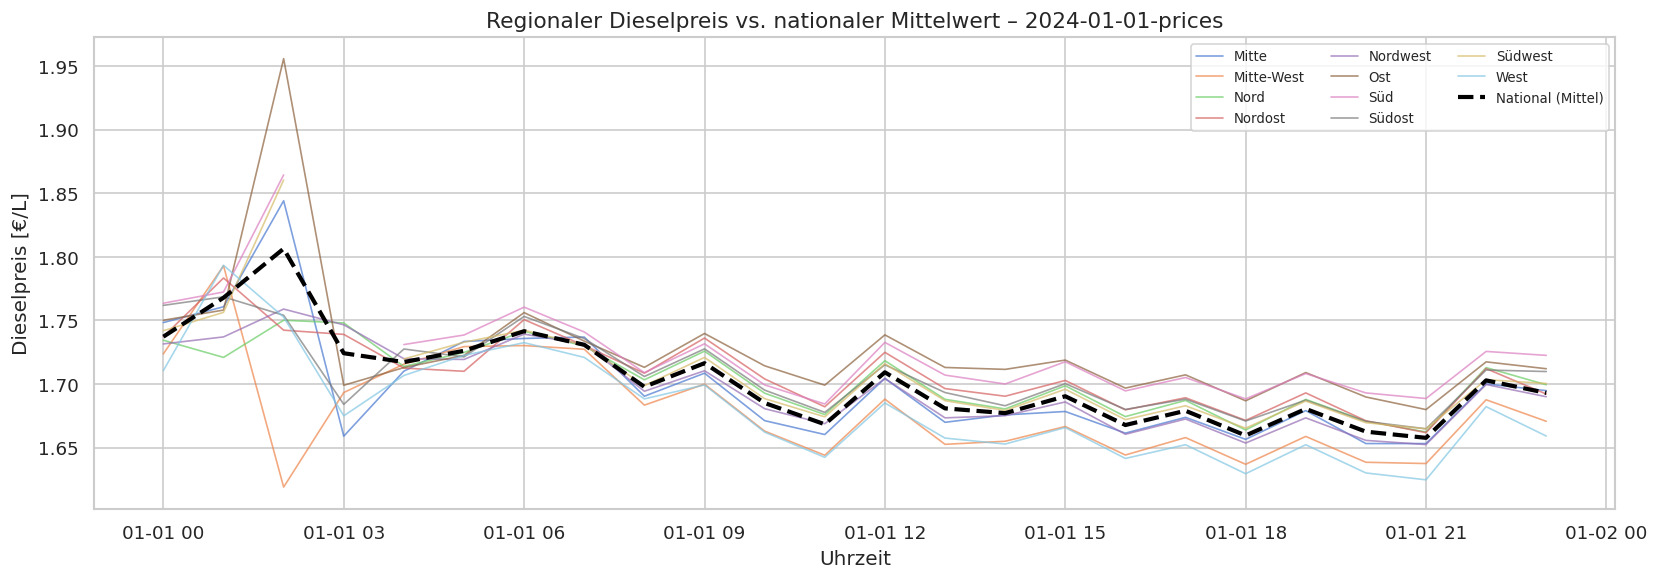

Mittlere Preisspanne zwischen Regionen: 6.32 Cent/L


In [16]:
# Visualisierung: Preisband National vs. Regionen (Beispieltag)

fig, ax = plt.subplots(figsize=(14, 5))

for col in regional_hourly.columns:
    ax.plot(regional_hourly.index, regional_hourly[col], lw=1, alpha=0.7, label=col)

# Nationaler Mittelwert als Referenz
national_hourly = (
    prices_enriched.groupby('hour')['diesel'].mean()
)
ax.plot(national_hourly.index, national_hourly.values,
        lw=2.5, color='black', ls='--', label='National (Mittel)')

ax.set_title(f'Regionaler Dieselpreis vs. nationaler Mittelwert – {Path(sample_files[0]).stem}',
             fontsize=13)
ax.set_ylabel('Dieselpreis [€/L]')
ax.set_xlabel('Uhrzeit')
ax.legend(loc='upper right', ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# Maximale Preisspanne zwischen den Regionen
spread = (regional_hourly.max(axis=1) - regional_hourly.min(axis=1)).mean()
print(f'Mittlere Preisspanne zwischen Regionen: {spread*100:.2f} Cent/L')

---
## §5 – Offene Fragen & nächste Schritte

**Entscheidungen:**
1. Wie groß ist die Preisspanne zwischen Regionen wirklich über alle Jahre? Lohnt sich ein regionales Modell für unsere Flotte?
2. Wie gehen wir mit `SONSTIGE` um – ausschließen oder als eigene Kategorie behalten?
3. Trainieren wir **ein Multi-Output-MLP** (alle Regionen gleichzeitig als Output) oder **separate Modelle pro Region**?
4. Reichen 10 PLZ-Regionen oder brauchen wir Bundesland-Genauigkeit?

**Nächste Schritte:**
- [ ] Vollständige Aggregation aller ~4.365 Tage → `hourly_regional_diesel.parquet`
- [ ] Marken-Aggregation (Top-10) → `hourly_brand_diesel.parquet`
- [ ] Preisspannenanalyse über den gesamten Zeitraum (2014–2026)
- [ ] Feature-Engineering für regionale Modelle (Brent als externe Variable aus Phase 2)